# 06 – Preprocessing NTHUDDD2: Face Detection & Eye Cropping via MediaPipe

Tujuan:
- Dataset NTHUDDD2 bawaan masih berupa gambar *full face*.
- Karena model backbone dilatih menggunakan dataset MRL (*crop* mata), kita perlu menyamakan domain.
- Notebook ini menggunakan **MediaPipe Face Mesh** untuk mendeteksi *landmark* wajah pada gambar NTHUDDD2 (hasil *split*).
- Jika terdeteksi, kita potong (crop) area yang mencakup kedua mata, me-*resize*-nya ke 224x224, lalu menyimpannya ke folder baru (`Dataset_nthuddd2_eye_SPLIT`).
- Jika MediaPipe gagal mendeteksi wajah pada sebuah *frame* (misal: gelap, terlalu miring), gambar tersebut tidak disimpan (sebagai *cleaning* natural).


# Import Library

In [62]:
import os
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
import shutil
from pathlib import Path
from PIL import Image
from collections import defaultdict
from tqdm import tqdm 

# Konfigurasi visual
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Cek MediaPipe version
print(f"MediaPipe Version : {mp.__version__}")
print(f"OpenCV Version    : {cv2.__version__}")

MediaPipe Version : 0.10.14
OpenCV Version    : 4.13.0


# Path Configuration

In [ ]:


BASE_DIR = r"C:\kuliah-sementara\SKRIPSI"

# Input: hasil SPLIT dari file 05_Preprocessing_Dataset_NTHUD.ipynb
INPUT_DIR = os.path.join(BASE_DIR, "Dataset_nthuddd2_SPLIT")

# Output: hasil crop per mata (kiri + kanan di-merge jadi 1 folder)
OUTPUT_DIR_MERGED = os.path.join(BASE_DIR, "Dataset_nthuddd2_eye_SPLIT")

# PERBAIKAN 1: Hapus CLASS_NAMES — sudah tidak dipakai, ganti semua pakai CLASSES
CLASSES     = ["drowsy", "notdrowsy"]
SPLITS      = ["train", "val", "test"]
TARGET_SIZE = (224, 224)

# margin_ratio dikecilkan dari 0.30 → 0.12 (domain alignment ke MRL)
# Kisaran rekomendasi: 0.10 (sangat ketat) — 0.15 (sedikit context)
MARGIN_RATIO = 0.12

# PERBAIKAN 2: Ganti OUTPUT_DIR → OUTPUT_DIR_MERGED (sesuai nama variable di atas)
# PERBAIKAN 3: Tambah print MARGIN_RATIO agar mudah dicek saat re-run
print(f"INPUT  DIR   : {INPUT_DIR}")
print(f"OUTPUT DIR   : {OUTPUT_DIR_MERGED}")
print(f"Target Size  : {TARGET_SIZE}")
print(f"Margin Ratio : {MARGIN_RATIO} ({MARGIN_RATIO*100:.0f}% padding per sisi)")

INPUT  DIR   : C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2_SPLIT
OUTPUT DIR   : C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2_eye_SPLIT
Target Size  : (224, 224)
Margin Ratio : 0.12 (12% padding per sisi)


# Cek Input & Cegah Overwrite

In [64]:
# ============================================================
#  VALIDASI PATH SEBELUM PROSES
# ============================================================

print("=" * 55)
print("VALIDASI STRUKTUR INPUT")
print("=" * 55)

input_ok = True
for split in SPLITS:
    # PERBAIKAN 1: CLASS_NAMES → CLASSES (variable yang benar)
    for cls in CLASSES:
        path = os.path.join(INPUT_DIR, split, cls)
        if os.path.exists(path):
            n = len([f for f in os.listdir(path)
                     if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
            print(f"  [OK] {split}/{cls} — {n:,} gambar")
        else:
            print(f"  [TIDAK ADA] {split}/{cls} — PATH TIDAK DITEMUKAN!")
            input_ok = False

print()

if not input_ok:
    raise FileNotFoundError(
        "Beberapa folder input tidak ditemukan. "
        "Cek INPUT_DIR dan jalankan file 05 terlebih dahulu."
    )

# ============================================================
#  CEK APAKAH OUTPUT SUDAH ADA (OVERWRITE PROTECTION)
# ============================================================
print("=" * 55)
print("CEK OUTPUT DIR")
print("=" * 55)

# PERBAIKAN 2: Semua OUTPUT_DIR → OUTPUT_DIR_MERGED
if os.path.exists(OUTPUT_DIR_MERGED):
    existing_files = sum(
        len([f for f in files if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
        for _, _, files in os.walk(OUTPUT_DIR_MERGED)
    )
    if existing_files > 0:
        print(f"[WARNING] OUTPUT_DIR_MERGED sudah berisi {existing_files:,} file gambar!")
        print(f"          Path: {OUTPUT_DIR_MERGED}")
        print()
        print("Pilihan:")
        print("  1. Hapus folder output secara manual lalu jalankan ulang.")
        print("  2. Lanjut tanpa re-run (skip cell eksekusi).")
        print()
        SKIP_PROCESS = True
    else:
        print(f"[OK] OUTPUT_DIR_MERGED kosong. Siap diproses.")
        SKIP_PROCESS = False
else:
    print(f"[OK] OUTPUT_DIR_MERGED belum ada. Akan dibuat otomatis.")
    SKIP_PROCESS = False

VALIDASI STRUKTUR INPUT
  [OK] train/drowsy — 22,671 gambar
  [OK] train/notdrowsy — 18,278 gambar
  [OK] val/drowsy — 10,596 gambar
  [OK] val/notdrowsy — 8,237 gambar
  [OK] test/drowsy — 2,767 gambar
  [OK] test/notdrowsy — 3,976 gambar

CEK OUTPUT DIR
[OK] OUTPUT_DIR_MERGED belum ada. Akan dibuat otomatis.


# Fungsi Helper: Square Bounding Box

In [65]:
def get_dual_eye_bounding_box(landmarks_list, img_w, img_h, margin_ratio=0.30):
    """
    [REFERENSI / FALLBACK] Hitung bounding box KOTAK kedua mata sekaligus.

    CATATAN: Fungsi ini TIDAK digunakan di pipeline utama Opsi C.
    Pipeline utama menggunakan get_single_eye_bbox() (per mata terpisah).
    Fungsi ini disimpan sebagai fallback jika get_single_eye_bbox() gagal
    mendeteksi salah satu mata (misal: wajah miring ekstrem).

    Args:
        landmarks_list : objek face_landmarks dari MediaPipe
        img_w, img_h   : dimensi gambar asli (pixel)
        margin_ratio   : margin proporsional per sisi (0.30 = +30% tiap sisi)

    Returns:
        (x1, y1, x2, y2) — koordinat kotak dalam pixel
    """
    xs = []
    ys = []

    for idx in LEFT_EYE_IDX + RIGHT_EYE_IDX:
        lm = landmarks_list.landmark[idx]
        xs.append(lm.x * img_w)
        ys.append(lm.y * img_h)

    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)

    w_eye = x_max - x_min
    h_eye = y_max - y_min

    # Paksa jadi kotak berdasarkan sisi TERPANJANG
    side = max(w_eye, h_eye)

    # Titik tengah antara kedua mata
    cx = (x_min + x_max) / 2
    cy = (y_min + y_max) / 2

    # Tambahkan margin proporsional
    pad  = side * margin_ratio
    half = (side + 2 * pad) / 2

    x1 = int(cx - half)
    y1 = int(cy - half)
    x2 = int(cx + half)
    y2 = int(cy + half)

    # Clamp agar tidak keluar batas gambar
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_w, x2)
    y2 = min(img_h, y2)

    return x1, y1, x2, y2

# Fungsi Crop Mata (MediaPipe)

In [66]:
# ============================================================
#  LANDMARK INDEX — Full Eye Contour (MediaPipe FaceMesh)
#  Ref: https://github.com/google/mediapipe/blob/master/mediapipe/
#       modules/face_geometry/data/canonical_face_model_uv_visualization.png
# ============================================================

# Left eye — 16 titik
LEFT_EYE_IDX = [
    33, 7, 163, 144, 145, 153, 154, 155,
    133, 173, 157, 158, 159, 160, 161, 246
]

# Right eye — 16 titik
RIGHT_EYE_IDX = [
    362, 382, 381, 380, 374, 373, 390, 249,
    263, 466, 388, 387, 386, 385, 384, 398
]


def get_single_eye_bbox(landmarks_list, eye_idx, img_w, img_h,
                        margin_ratio=0.12):
    """
    Hitung bounding box KOTAK untuk SATU MATA saja.

    Args:
        landmarks_list : face_landmarks dari MediaPipe
        eye_idx        : list index (LEFT_EYE_IDX atau RIGHT_EYE_IDX)
        img_w, img_h   : dimensi gambar asli (pixel)
        margin_ratio   : padding proporsional (0.12 = 12% per sisi)

    Returns:
        (x1, y1, x2, y2) dalam pixel, atau None jika terlalu kecil
    """
    xs = [landmarks_list.landmark[idx].x * img_w for idx in eye_idx]
    ys = [landmarks_list.landmark[idx].y * img_h for idx in eye_idx]

    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)

    side = max(x_max - x_min, y_max - y_min)
    cx   = (x_min + x_max) / 2
    cy   = (y_min + y_max) / 2

    pad  = side * margin_ratio
    half = (side / 2) + pad

    x1 = max(0,     int(cx - half))
    y1 = max(0,     int(cy - half))
    x2 = min(img_w, int(cx + half))
    y2 = min(img_h, int(cy + half))

    if (x2 - x1) < 20 or (y2 - y1) < 20:
        return None

    return x1, y1, x2, y2


def crop_eye_region(image_bgr, facemesh_results, eye_idx,
                    target_size=(224, 224)):
    """
    Crop region SATU MATA dari gambar berdasarkan landmark FaceMesh.

    Args:
        image_bgr        : gambar OpenCV (BGR)
        facemesh_results : hasil process() dari MediaPipe FaceMesh
        eye_idx          : LEFT_EYE_IDX atau RIGHT_EYE_IDX
        target_size      : ukuran output (default 224x224)

    Returns:
        PIL.Image atau None jika gagal
    """
    if not facemesh_results.multi_face_landmarks:
        return None

    face_landmarks = facemesh_results.multi_face_landmarks[0]
    h, w = image_bgr.shape[:2]

    img_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # PERBAIKAN 1: get_square_bounding_box → get_single_eye_bbox
    # (nama fungsi lama sudah tidak ada, sesuai Opsi C)
    bbox = get_single_eye_bbox(face_landmarks, eye_idx, w, h,
                               margin_ratio=MARGIN_RATIO)
    if bbox is None:
        return None

    x1, y1, x2, y2 = bbox
    crop = img_rgb[y1:y2, x1:x2]

    if crop.size == 0:
        return None

    # PERBAIKAN 2: cv2.INTER_AREA → PIL LANCZOS
    # LANCZOS lebih tajam dan minim artefak untuk downscale ke 224x224
    pil_img = Image.fromarray(crop)
    pil_img = pil_img.resize(target_size, Image.Resampling.LANCZOS)

    return pil_img

# Fungsi Utama: Process & Crop Dataset

In [67]:
def process_and_crop_dataset(input_base, output_base, splits, classes,
                              target_size=(224, 224), margin_ratio=0.12,
                              min_conf=0.5):
    stats = {
        split: {
            cls: {
                "success_both": 0,
                "success_one":  0,
                "fail_no_face": 0,
                "fail_both":    0,
                "fail_io":      0
            }
            for cls in classes
        }
        for split in splits
    }

    # KUNCI FIX: definisi lokal — tidak bergantung variable global
    _mp_face_mesh = mp.solutions.face_mesh

    with _mp_face_mesh.FaceMesh(
        static_image_mode=True,
        max_num_faces=1,
        refine_landmarks=True,
        min_detection_confidence=min_conf
    ) as face_mesh:

        for split in splits:
            for cls in classes:
                src_dir = os.path.join(input_base, split, cls)
                dst_dir = os.path.join(output_base, split, cls)
                os.makedirs(dst_dir, exist_ok=True)

                if not os.path.exists(src_dir):
                    print(f"[SKIP] Tidak ditemukan: {src_dir}")
                    continue

                files = [
                    f for f in os.listdir(src_dir)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
                ]

                print(f"{split.upper()}/{cls} — Memproses {len(files):,} gambar...")

                for fname in tqdm(files, leave=False):
                    src_path  = os.path.join(src_dir, fname)
                    stem, ext = os.path.splitext(fname)

                    try:
                        img_bgr = cv2.imread(src_path)
                        if img_bgr is None:
                            stats[split][cls]["fail_io"] += 1
                            continue

                        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
                        h, w    = img_bgr.shape[:2]

                        results = face_mesh.process(img_rgb)

                        if not results.multi_face_landmarks:
                            stats[split][cls]["fail_no_face"] += 1
                            continue

                        landmarks   = results.multi_face_landmarks[0]
                        saved_count = 0

                        for eye_label, eye_idx in [("L", LEFT_EYE_IDX),
                                                    ("R", RIGHT_EYE_IDX)]:
                            bbox = get_single_eye_bbox(
                                landmarks, eye_idx, w, h,
                                margin_ratio=margin_ratio
                            )
                            if bbox is None:
                                continue

                            x1, y1, x2, y2 = bbox
                            crop_rgb = img_rgb[y1:y2, x1:x2]

                            if crop_rgb.size == 0:
                                continue

                            pil_img = Image.fromarray(crop_rgb)
                            pil_img = pil_img.resize(
                                target_size, Image.Resampling.LANCZOS
                            )

                            out_fname = f"{stem}_{eye_label}{ext}"
                            out_path  = os.path.join(dst_dir, out_fname)
                            pil_img.save(out_path, quality=95)
                            saved_count += 1

                        if saved_count == 2:
                            stats[split][cls]["success_both"] += 1
                        elif saved_count == 1:
                            stats[split][cls]["success_one"]  += 1
                        else:
                            stats[split][cls]["fail_both"]    += 1

                    except Exception:
                        stats[split][cls]["fail_io"] += 1
                        continue

    return stats

# Eksekusi Proses

In [68]:
if SKIP_PROCESS:
    print("[SKIP] Output sudah ada. Jalankan investigasi / verifikasi saja.")
else:
    print("Memulai proses single-eye crop per mata (Opsi C)...\n")
    CROP_STATS = process_and_crop_dataset(
        input_base   = INPUT_DIR,
        output_base  = OUTPUT_DIR_MERGED,
        splits       = SPLITS,
        classes      = CLASSES,
        target_size  = TARGET_SIZE,
        margin_ratio = MARGIN_RATIO,
        min_conf     = 0.5
    )
    print("\n✓ Proses single-eye crop selesai.")

Memulai proses single-eye crop per mata (Opsi C)...

TRAIN/drowsy — Memproses 22,671 gambar...


  0%|          | 3/22671 [00:00<12:38, 29.88it/s]

TRAIN/notdrowsy — Memproses 18,278 gambar...


VAL/drowsy — Memproses 10,596 gambar...


VAL/notdrowsy — Memproses 8,237 gambar...


TEST/drowsy — Memproses 2,767 gambar...


TEST/notdrowsy — Memproses 3,976 gambar...



✓ Proses single-eye crop selesai.


# Laporan Failure per Kelas 
mendeteksi apakah drowsy lebih sering gagal.

In [71]:
W = 80  # diperlebar sedikit karena kolom bertambah

print("=" * W)
print("LAPORAN FAILURE RATE — SINGLE-EYE CROP (OPSI C)")
print("=" * W)
print(f"  {'Split/Kelas':<22} {'Both OK':>8} {'One OK':>8} "
      f"{'No Face':>8} {'Both Fail':>9} {'IO Err':>7} {'Fail%':>6}")
print("-" * W)

total_success = 0
total_fail    = 0

for split in SPLITS:
    # PERBAIKAN 1: CLASS_NAMES → CLASSES
    for cls in CLASSES:
        s = CROP_STATS[split][cls]

        # PERBAIKAN 2: key lama ("success","fail_crop") →
        # key baru Opsi C ("success_both","success_one","fail_both")
        total_items  = (s["success_both"] + s["success_one"] +
                        s["fail_no_face"] + s["fail_both"] + s["fail_io"])
        total_fail_n = s["fail_no_face"] + s["fail_both"] + s["fail_io"]
        fail_pct     = (total_fail_n / total_items * 100) if total_items > 0 else 0

        print(f"  {split+'/'+cls:<22} "
              f"{s['success_both']:>8,} "
              f"{s['success_one']:>8,} "
              f"{s['fail_no_face']:>8,} "
              f"{s['fail_both']:>9,} "
              f"{s['fail_io']:>7,} "
              f"{fail_pct:>6.2f}%")

        total_success += s["success_both"] + s["success_one"]
        total_fail    += total_fail_n

# PERBAIKAN 3: tambah estimasi total output files
# (success_both = 2 file, success_one = 1 file)
total_output_files = sum(
    CROP_STATS[sp][cl]["success_both"] * 2 + CROP_STATS[sp][cl]["success_one"]
    for sp in SPLITS for cl in CLASSES
)

print("=" * W)
print(f"  {'TOTAL INPUT':<22} {total_success + total_fail:>8,}")
print(f"  Total Output Files   : {total_output_files:,} (~2x karena 2 mata per gambar)")
print(f"  Total Gagal          : {total_fail:,}")
print(f"  Success Rate         : "
      f"{total_success / (total_success + total_fail) * 100:.2f}%")
print("=" * W)

# ── Analisis class bias ──
print("\n[ANALISIS CLASS BIAS]")
for split in SPLITS:
    fail_rates = {}
    # PERBAIKAN 1 (lanjutan): CLASS_NAMES → CLASSES
    for cls in CLASSES:
        s = CROP_STATS[split][cls]
        total_items = (s["success_both"] + s["success_one"] +
                       s["fail_no_face"] + s["fail_both"] + s["fail_io"])
        fail_n = s["fail_no_face"] + s["fail_both"] + s["fail_io"]
        fail_rates[cls] = (fail_n / total_items * 100) if total_items > 0 else 0

    diff = abs(fail_rates["drowsy"] - fail_rates["notdrowsy"])
    if diff > 5:
        print(f"  [WARNING] {split.upper()}: drowsy {fail_rates['drowsy']:.2f}%"
              f" vs notdrowsy {fail_rates['notdrowsy']:.2f}% — selisih {diff:.2f}%!")
        print(f"            → Distribusi kelas berubah setelah crop. Investigasi diperlukan.")
    else:
        print(f"  [OK]      {split.upper()}: Seimbang (diff={diff:.2f}%)")

LAPORAN FAILURE RATE — SINGLE-EYE CROP (OPSI C)
  Split/Kelas             Both OK   One OK  No Face Both Fail  IO Err  Fail%
--------------------------------------------------------------------------------
  train/drowsy             22,662        0        9         0       0   0.04%
  train/notdrowsy          17,797      352      129         0       0   0.71%
  val/drowsy               10,596        0        0         0       0   0.00%
  val/notdrowsy             7,719      104      414         0       0   5.03%
  test/drowsy               2,767        0        0         0       0   0.00%
  test/notdrowsy            3,783       83      110         0       0   2.77%
  TOTAL INPUT              66,525
  Total Output Files   : 131,187 (~2x karena 2 mata per gambar)
  Total Gagal          : 662
  Success Rate         : 99.00%

[ANALISIS CLASS BIAS]
  [OK]      TRAIN: Seimbang (diff=0.67%)
  [WARNING] VAL: drowsy 0.00% vs notdrowsy 5.03% — selisih 5.03%!
            → Distribusi kelas beruba

# CHEK APAKAH ADA KEPALA MIRING (BELUM RUN)

Total gagal: 414


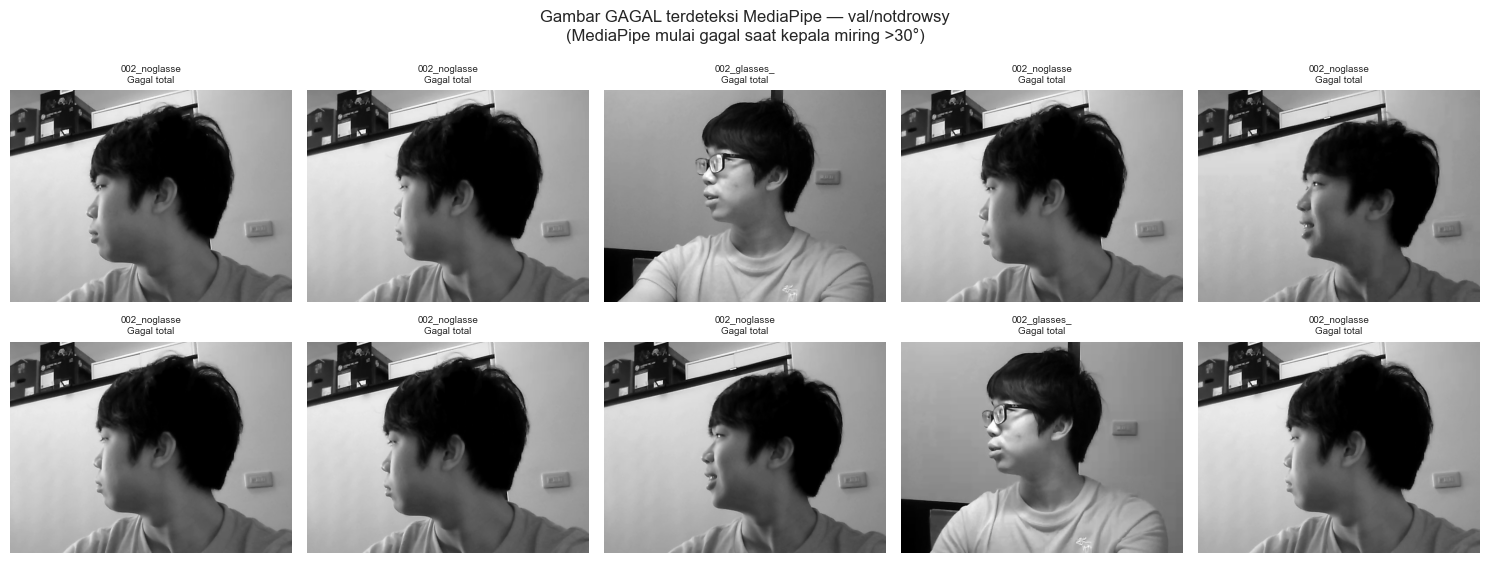

In [73]:
import random

FAIL_SPLIT = "val"
FAIL_CLASS = "notdrowsy"

output_files = set(
    os.path.splitext(f)[0].rsplit('_', 1)[0]
    for f in os.listdir(
        os.path.join(OUTPUT_DIR_MERGED, FAIL_SPLIT, FAIL_CLASS)
    )
    if f.lower().endswith(('.jpg', '.png'))
)

input_files = [
    f for f in os.listdir(os.path.join(INPUT_DIR, FAIL_SPLIT, FAIL_CLASS))
    if f.lower().endswith(('.jpg', '.png'))
]

failed_files = [
    f for f in input_files
    if os.path.splitext(f)[0] not in output_files
]

print(f"Total gagal: {len(failed_files)}")

sample_fails = random.sample(failed_files, min(10, len(failed_files)))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(
    f"Gambar GAGAL terdeteksi MediaPipe — {FAIL_SPLIT}/{FAIL_CLASS}\n"
    f"(MediaPipe mulai gagal saat kepala miring >30°)",
    fontsize=12
)

# FIX: buat FaceMesh SEKALI di luar loop gambar
# (lebih efisien dan tidak bergantung variable global)
with mp.solutions.face_mesh.FaceMesh(
    static_image_mode=True, max_num_faces=1,
    refine_landmarks=True, min_detection_confidence=0.3
) as fm:

    for i, fname in enumerate(sample_fails):
        ax       = axes[i // 5][i % 5]
        img_path = os.path.join(INPUT_DIR, FAIL_SPLIT, FAIL_CLASS, fname)
        img      = cv2.imread(img_path)
        img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        results = fm.process(img_rgb)

        if results.multi_face_landmarks:
            lm    = results.multi_face_landmarks[0].landmark
            dx    = (lm[263].x - lm[33].x) * img.shape[1]
            dy    = (lm[263].y - lm[33].y) * img.shape[0]
            angle = abs(np.degrees(np.arctan2(dy, dx)))
            title = f"{fname[:12]}\n~{angle:.1f}° miring"
        else:
            title = f"{fname[:12]}\nGagal total"

        ax.imshow(img_rgb)
        ax.set_title(title, fontsize=7)
        ax.axis('off')

plt.tight_layout()
plt.show()

# Verifikasi Distribusi Output 

In [74]:
W = 75  
print("=" * W)
print("DISTRIBUSI OUTPUT SETELAH SINGLE-EYE CROP (OPSI C)")
print("=" * W)
print(f"  {'Split/Kelas':<22} {'Input':>8} {'Output':>8} {'Ratio':>7} {'Drop%':>7}")
print("-" * W)

grand_input  = 0
grand_output = 0

for split in SPLITS:
    print(f"\n  {split.upper()} SET")
    split_in  = 0
    split_out = 0

    # PERBAIKAN 1: CLASS_NAMES → CLASSES
    for cls in CLASSES:
        in_path  = os.path.join(INPUT_DIR,        split, cls)
        # PERBAIKAN 2: OUTPUT_DIR → OUTPUT_DIR_MERGED
        out_path = os.path.join(OUTPUT_DIR_MERGED, split, cls)

        n_in  = len([f for f in os.listdir(in_path)
                     if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
        n_out = len([f for f in os.listdir(out_path)
                     if f.lower().endswith(('.jpg', '.png', '.jpeg'))])

        # PERBAIKAN 3: logika "drop" disesuaikan
        # Output Opsi C bisa sampai 2× input (2 mata per gambar)
        # Jadi yang relevan adalah ratio, bukan "dropped"
        ratio    = (n_out / (n_in * 2) * 100) if n_in > 0 else 0
        drop_pct = 100 - ratio

        print(f"  {cls:<22} {n_in:>8,} {n_out:>8,} {ratio:>6.1f}%  {drop_pct:>6.2f}%")
        split_in  += n_in
        split_out += n_out

    # PERBAIKAN 1 (lanjutan): CLASS_NAMES → CLASSES
    balance = {}
    for cls in CLASSES:
        # PERBAIKAN 2 (lanjutan): OUTPUT_DIR → OUTPUT_DIR_MERGED
        out_path     = os.path.join(OUTPUT_DIR_MERGED, split, cls)
        balance[cls] = len([f for f in os.listdir(out_path)
                            if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
    total_out = sum(balance.values())
    if total_out > 0:
        ratios = "  ".join(
            [f"{cls}: {balance[cls]/total_out*100:.2f}%" for cls in CLASSES]
        )
        print(f"  Rasio kelas → {ratios}")

    grand_input  += split_in
    grand_output += split_out

print()
print("=" * W)
print(f"  GRAND TOTAL INPUT        : {grand_input:,}")
print(f"  GRAND TOTAL OUTPUT       : {grand_output:,} (~2x karena 2 mata per gambar)")
print(f"  EKSPEKTASI MAX OUTPUT    : {grand_input * 2:,}")
print(f"  EFISIENSI CROP           : {grand_output / (grand_input * 2) * 100:.2f}%")
print("=" * W)

DISTRIBUSI OUTPUT SETELAH SINGLE-EYE CROP (OPSI C)
  Split/Kelas               Input   Output   Ratio   Drop%
---------------------------------------------------------------------------

  TRAIN SET
  drowsy                   22,671   45,324  100.0%    0.04%
  notdrowsy                18,278   35,946   98.3%    1.67%
  Rasio kelas → drowsy: 55.77%  notdrowsy: 44.23%

  VAL SET
  drowsy                   10,596   21,192  100.0%    0.00%
  notdrowsy                 8,237   15,542   94.3%    5.66%
  Rasio kelas → drowsy: 57.69%  notdrowsy: 42.31%

  TEST SET
  drowsy                    2,767    5,534  100.0%    0.00%
  notdrowsy                 3,976    7,649   96.2%    3.81%
  Rasio kelas → drowsy: 41.98%  notdrowsy: 58.02%

  GRAND TOTAL INPUT        : 66,525
  GRAND TOTAL OUTPUT       : 131,187 (~2x karena 2 mata per gambar)
  EKSPEKTASI MAX OUTPUT    : 133,050
  EFISIENSI CROP           : 98.60%


# Visualisasi Grid per Kondisi

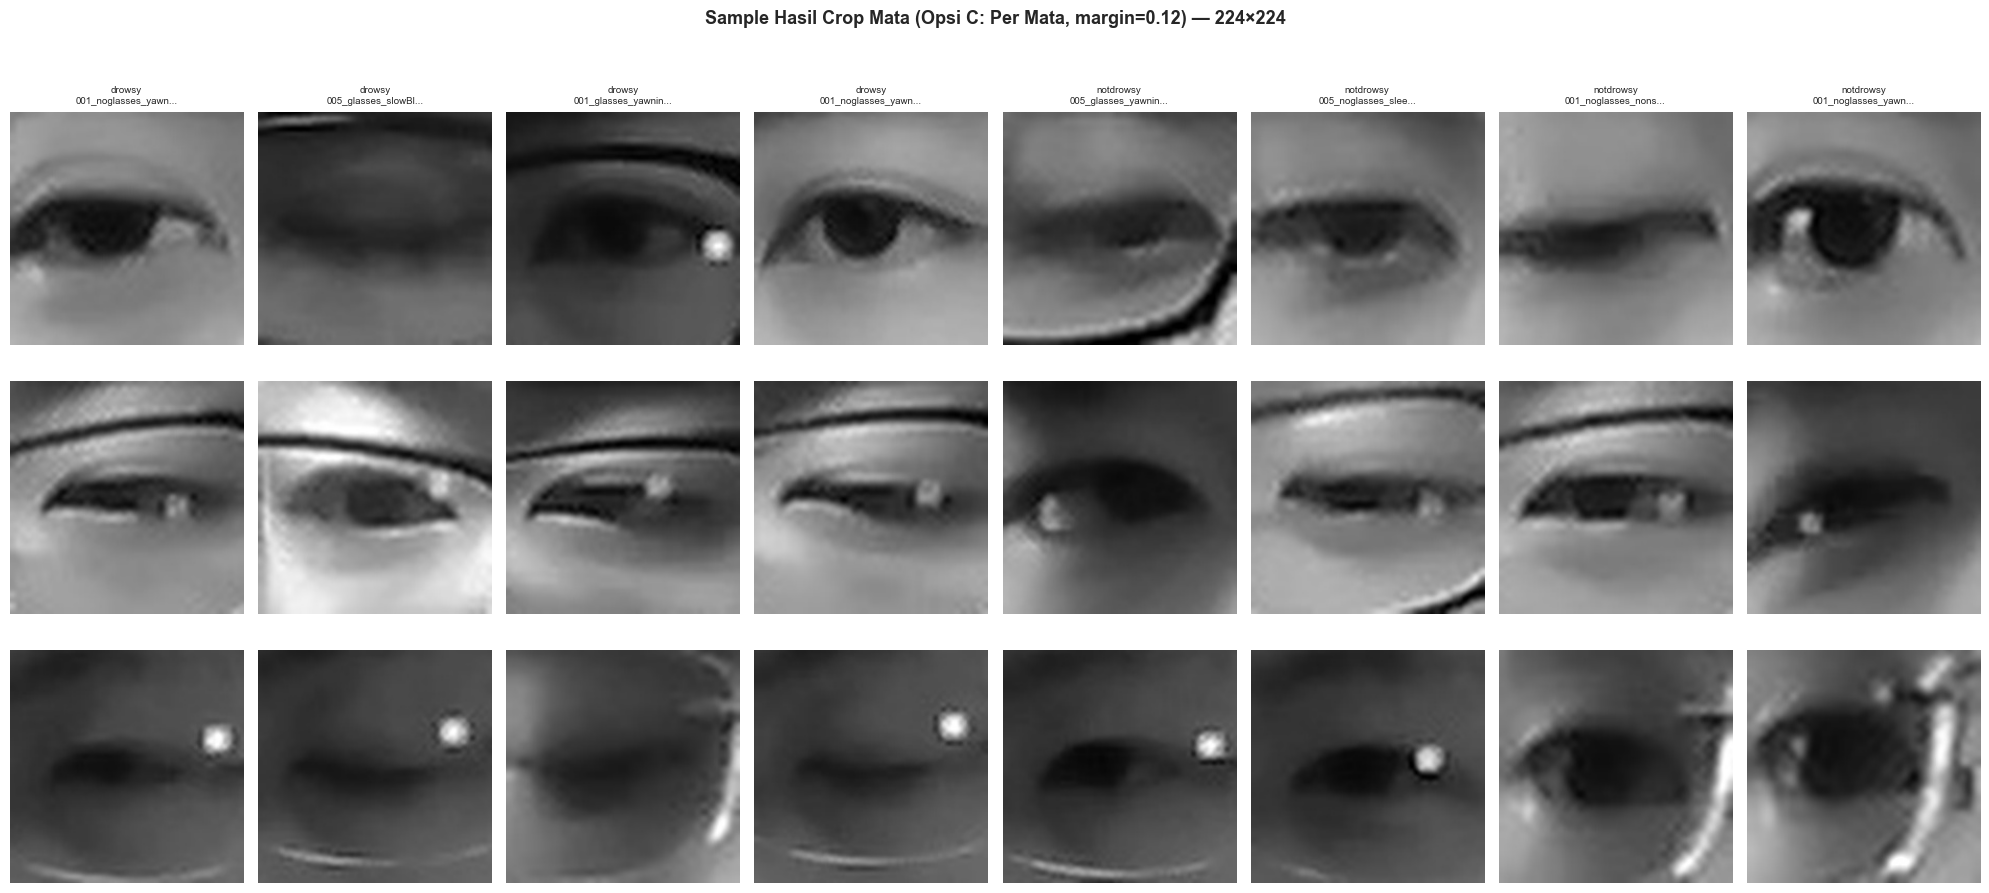

In [ ]:
SAMPLES_PER_CELL = 4

fig, axes = plt.subplots(
    nrows=len(SPLITS),
    # PERBAIKAN 1: CLASS_NAMES → CLASSES
    ncols=len(CLASSES) * SAMPLES_PER_CELL,
    figsize=(SAMPLES_PER_CELL * len(CLASSES) * 2.5, len(SPLITS) * 3)
)

for row_idx, split in enumerate(SPLITS):
    # PERBAIKAN 1 (lanjutan): CLASS_NAMES → CLASSES
    for col_group, cls in enumerate(CLASSES):
        # PERBAIKAN 2: OUTPUT_DIR → OUTPUT_DIR_MERGED
        out_path  = os.path.join(OUTPUT_DIR_MERGED, split, cls)
        all_files = [
            f for f in os.listdir(out_path)
            if f.lower().endswith(('.jpg', '.png', '.jpeg'))
        ]

        sampled = np.random.choice(
            all_files,
            min(SAMPLES_PER_CELL, len(all_files)),
            replace=False
        )

        for i, fname in enumerate(sampled):
            col_idx = col_group * SAMPLES_PER_CELL + i
            ax      = axes[row_idx][col_idx]

            img     = cv2.imread(os.path.join(out_path, fname))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img_rgb)
            ax.axis("off")

            if i == 0:
                ax.set_ylabel(f"{split}", fontsize=9, fontweight='bold')
            if row_idx == 0:
                ax.set_title(f"{cls}\n{fname[:18]}...", fontsize=7)

plt.suptitle(
    "Sample Hasil Crop Mata (Opsi C: Per Mata, margin=0.12) — 224×224",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# Cek Kualitas File Output (Corrupt Check)

In [76]:
# ============================================================
#  CEK FILE CORRUPT DI OUTPUT
# ============================================================

print("Memeriksa integritas file output...")
print("=" * 55)

corrupt_files = []

for split in SPLITS:
    # PERBAIKAN 1: CLASS_NAMES → CLASSES
    for cls in CLASSES:
        # PERBAIKAN 2: OUTPUT_DIR → OUTPUT_DIR_MERGED
        out_path = os.path.join(OUTPUT_DIR_MERGED, split, cls)
        files    = [f for f in os.listdir(out_path)
                    if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

        for fname in files:
            fpath = os.path.join(out_path, fname)
            try:
                img = Image.open(fpath)
                img.verify()
                img = Image.open(fpath)
                img.load()

                # Validasi ukuran harus 224x224
                w, h = img.size
                if w != TARGET_SIZE[0] or h != TARGET_SIZE[1]:
                    print(f"[SIZE ERROR] {split}/{cls}/{fname} — size: {w}×{h}")
                    corrupt_files.append(fpath)

            except Exception as e:
                print(f"[CORRUPT] {split}/{cls}/{fname} — {str(e)}")
                corrupt_files.append(fpath)
                os.remove(fpath)

print()
if len(corrupt_files) == 0:
    print("[OK] Semua file output valid dan berukuran 224×224.")
else:
    print(f"[WARNING] Ditemukan {len(corrupt_files)} file bermasalah (sudah dihapus).")

print("=" * 55)
print("PROSES FILE 06 SELESAI — SIAP LANJUT KE FILE 07 (Ekstraksi Fitur)")

Memeriksa integritas file output...

[OK] Semua file output valid dan berukuran 224×224.
PROSES FILE 06 SELESAI — SIAP LANJUT KE FILE 07 (Ekstraksi Fitur)
